In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import re
from brf_lightning.data.bearing.utils import load_vibration_data
from brf_lightning.utils.kurtogram import spectral_kurtosis

def sweep_sk_band_selection(x, fs, band_width=1000.0, step_size=200.0,
                            min_freq=100.0, max_freq=None, nperseg=8192):
    f, sk = spectral_kurtosis(x, fs, nperseg=nperseg)
    if max_freq is None:
        max_freq = f.max() - band_width

    bands = []
    for f_lo in np.arange(min_freq, max_freq, step_size):
        f_hi = f_lo + band_width
        mask = (f >= f_lo) & (f < f_hi)
        if mask.sum() == 0:
            continue
        mean_sk = sk[mask].mean()
        max_sk = sk[mask].max()
        bands.append((f_lo, f_hi, mean_sk, max_sk))
    bands.sort(key=lambda tup: tup[2], reverse=True)  # by mean kurtosis
    return bands, f, sk

# ──── MAIN LOOP OVER FILES ───────────────────────────────
root_dir = Path("data/bearing_thl_v1")
csv_files = sorted(f for f in root_dir.glob("*.csv") if not re.search(r'n\d+\.csv', f.name))

results = []

for file in csv_files:
    df, fs = load_vibration_data(file)
    x = df['sensor_bearing'].values
    bands, f, sk = sweep_sk_band_selection(x, fs)
    best_band = bands[0]
    print(f"{file.name:<12}  best band: {best_band[0]:.0f}–{best_band[1]:.0f} Hz  mean SK = {best_band[2]:.2f}")

    results.append({
        'file': file.name,
        'fs': fs,
        'best_band_lo': best_band[0],
        'best_band_hi': best_band[1],
        'mean_sk': best_band[2],
        'max_sk': best_band[3]
    })

# Optional: convert to DataFrame and analyze
results_df = pd.DataFrame(results)


fAII10.csv    best band: 100–1100 Hz  mean SK = -2.00
fAII20.csv    best band: 1900–2900 Hz  mean SK = -1.08
fAII30.csv    best band: 2100–3100 Hz  mean SK = 0.04
fIII10.csv    best band: 100–1100 Hz  mean SK = -1.64
fIII20.csv    best band: 1100–2100 Hz  mean SK = 0.56
fIII30.csv    best band: 1700–2700 Hz  mean SK = 2.53


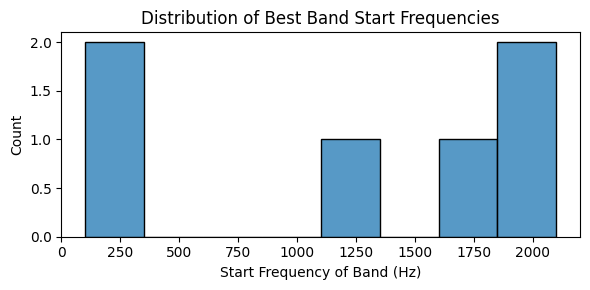

In [6]:
import seaborn as sns
plt.figure(figsize=(6,3))
sns.histplot(results_df['best_band_lo'], binwidth=250)
plt.title("Distribution of Best Band Start Frequencies")
plt.xlabel("Start Frequency of Band (Hz)")
plt.tight_layout()


In [9]:
from brf_lightning.utils.kurtogram import kurtogram

def plot_kurtogram(K, levels, fs):
    fig, ax = plt.subplots(figsize=(8, 5))
    extent = [0, fs / 2, 0, len(levels)]  # freq from 0 to Nyquist
    im = ax.imshow(K, aspect='auto', origin='lower', extent=extent, cmap='viridis')
    ax.set_ylabel("Level")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_title("Kurtogram (kurtosis heatmap)")
    fig.colorbar(im, ax=ax, label='Kurtosis')
    plt.tight_layout()

def kurtogram_band_bounds(fs, level, order):
    total_bandwidth = fs / 2
    band_width = total_bandwidth / (2 ** level)
    f_lo = max(order * band_width, 1e-6)
    f_hi = (order + 1) * band_width
    return f_lo, f_hi

K, levels, Ls, os = kurtogram(x, fs)
f_lo, f_hi = kurtogram_band_bounds(fs, Ls, os)
print(f"Best band from kurtogram: {f_lo:.1f}-{f_hi:.1f} Hz at level {Ls}, order {os}")

df, fs = load_vibration_data(Path("data/bearing_thl_v1/fAII10.csv"))
x = df['sensor_bearing'].values

K, levels, Ls, os = kurtogram(x, fs, max_level=6)
plot_kurtogram(K, levels, fs)

f_lo, f_hi = kurtogram_band_bounds(fs, Ls, os)
print(f"Best kurtosis band: {f_lo:.1f}–{f_hi:.1f} Hz")



ValueError: filter critical frequencies must be greater than 0